In [2]:
# Importar las librerias necesarias
import os
import sklearn
import pandas as pd
import numpy as np
from sklearn import datasets
import matplotlib.pyplot as plt
import statsmodels.api as smEEe
from scipy import stats
import seaborn as sns
import statsmodels.api as sm
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn import metrics
from sklearn.model_selection import train_test_split, GridSearchCV
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import RandomOverSampler
from sklearn.datasets import load_breast_cancer
from sklearn.datasets import make_classification

In [21]:
# Se carga la data del cancer de mama
data = load_breast_cancer()
# Se Ajustan las variables deseadas
X = data.data
y = data.target
# Se establecen las etiquetas y las caracteristicas
feature_names = data.feature_names
target_names = data.target_names

In [8]:
# Convertir la variable objetivo a un DataFrame de Pandas
y_df = pd.DataFrame(y, columns=['Target'])

# Crear una tabla de frecuencia
freq_table = y_df['Target'].value_counts().reset_index()
freq_table.columns = ['Clase', 'Frecuencia']

# Si tienes los nombres de las clases, puedes reemplazar los números por los nombres
# Por ejemplo, en el conjunto de datos de cáncer de mama de sklearn, 0 representa 'maligno' y 1 representa 'benigno'
freq_table['Clase'].replace({0: 'Maligno', 1: 'Benigno'}, inplace=True)

# Mostrar la tabla de frecuencia
print(freq_table)

     Clase  Frecuencia
0  Benigno         357
1  Maligno         212


In [9]:
# Creacion del modelo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [10]:
import pandas as pd

# Convertir la variable objetivo a un DataFrame de Pandas
y_df = pd.DataFrame(y_train, columns=['Target'])

# Crear una tabla de frecuencia
freq_table = y_df['Target'].value_counts().reset_index()
freq_table.columns = ['Clase', 'Frecuencia']

# Si tienes los nombres de las clases, puedes reemplazar los números por los nombres
# Por ejemplo, en el conjunto de datos de cáncer de mama de sklearn, 0 representa 'maligno' y 1 representa 'benigno'
freq_table['Clase'].replace({0: 'Maligno', 1: 'Benigno'}, inplace=True)

# Mostrar la tabla de frecuencia
print(freq_table)

     Clase  Frecuencia
0  Benigno         285
1  Maligno         170


In [24]:
# Clasificador en el Decision Tree
clf = DecisionTreeClassifier(random_state=1, max_depth=3)

In [25]:
# Agrega
clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=1)

In [13]:
y_pred = clf.predict(X_test)

In [15]:
accuracy = metrics.accuracy_score(y_test, y_pred)
precision = metrics.precision_score(y_test, y_pred, average='weighted')

print(f'Exactitud del modelo: {accuracy * 100:.2f}%')
print(f'Precisión del modelo: {precision * 100:.2f}%')

Exactitud del modelo: 91.23%
Precisión del modelo: 91.19%


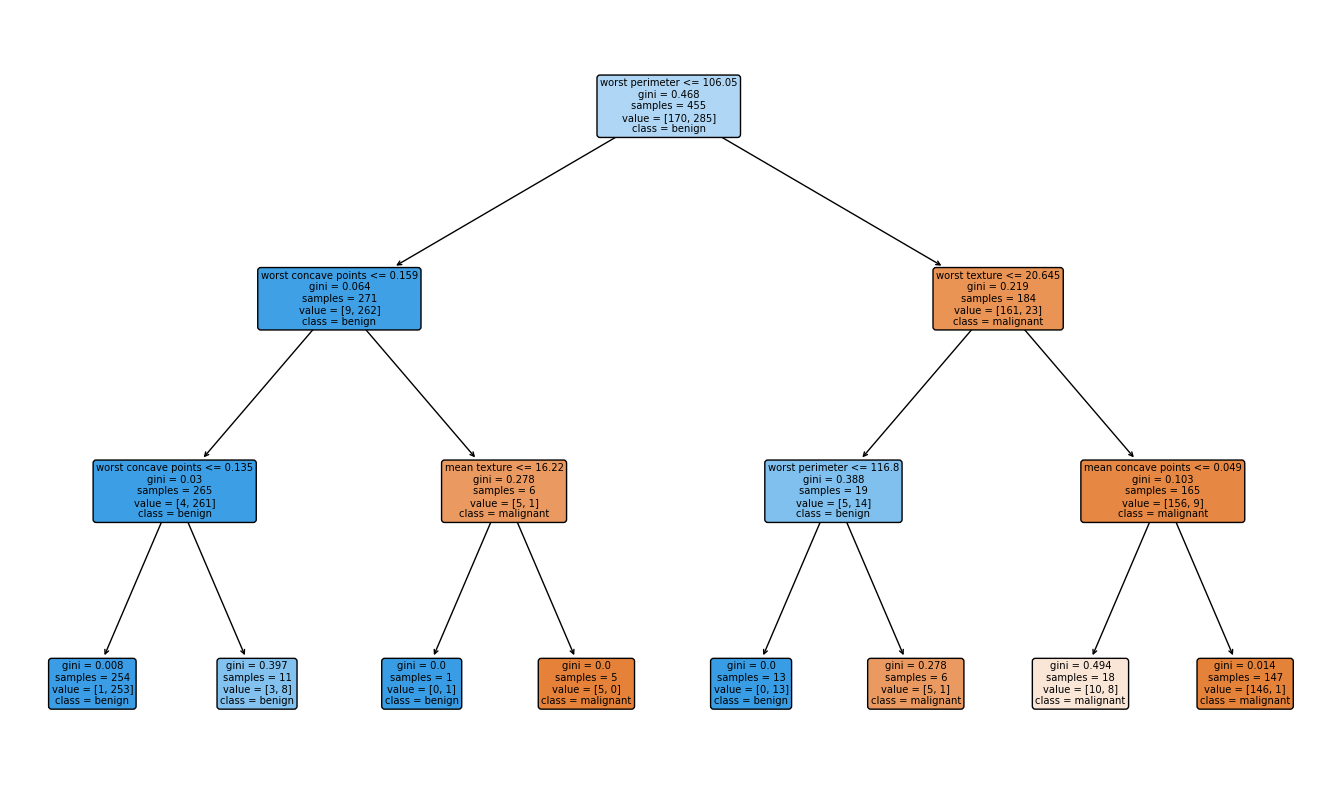

In [23]:
# Crear la visualización del árbol
plt.figure(figsize=(17, 10))  # Cambia el tamaño de la figura según las preferencias
tree.plot_tree(clf, filled=True, feature_names=feature_names, class_names=target_names, rounded=True)
plt.show()

In [19]:
def extract_rules_to_dataframe(tree, feature_names, class_names):
    n_nodes = tree.tree_.node_count
    children_left = tree.tree_.children_left
    children_right = tree.tree_.children_right
    feature = tree.tree_.feature
    threshold = tree.tree_.threshold
    values = tree.tree_.value

    rules = []
    segments = []

    def recurse(node, rule):
        if children_left[node] != children_right[node]:
            name = feature_names[feature[node]]
            thres = threshold[node]
            recurse(children_left[node], rule + [f"{name} <= {thres:.2f}"])
            recurse(children_right[node], rule + [f"{name} > {thres:.2f}"])
        else:
            class_name = class_names[np.argmax(values[node])]
            rules.append(" AND ".join(rule))
            segments.append(class_name)

    recurse(0, [])
    df = pd.DataFrame({'Rule': rules, 'Segment': segments})
    return df

# Extraer las reglas a un DataFrame
df_rules = extract_rules_to_dataframe(clf, feature_names, data.target_names)

pd.set_option('display.max_rows', None)
df_rules

,Rule,Segment
0,worst perimeter <= 106.05 AND worst concave po...,benign
1,worst perimeter <= 106.05 AND worst concave po...,benign
2,worst perimeter <= 106.05 AND worst concave po...,benign
3,worst perimeter <= 106.05 AND worst concave po...,malignant
4,worst perimeter > 106.05 AND worst texture <= ...,benign
5,worst perimeter > 106.05 AND worst texture <= ...,malignant
6,worst perimeter > 106.05 AND worst texture > 2...,malignant
7,worst perimeter > 106.05 AND worst texture > 2...,malignant


In [26]:
feature_importances = clf.feature_importances_

df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Ordenar el DataFrame por importancia
df_importance = df_importance.sort_values('Importance', ascending=False)

# Mostrar la importancia de las características
df_importance

,Feature,Importance
22,worst perimeter,0.829686
21,worst texture,0.081741
27,worst concave points,0.048332
7,mean concave points,0.031653
1,mean texture,0.008588
0,mean radius,0.000000
16,concavity error,0.000000
28,worst symmetry,0.000000
26,worst concavity,0.000000
25,worst compactness,0.000000


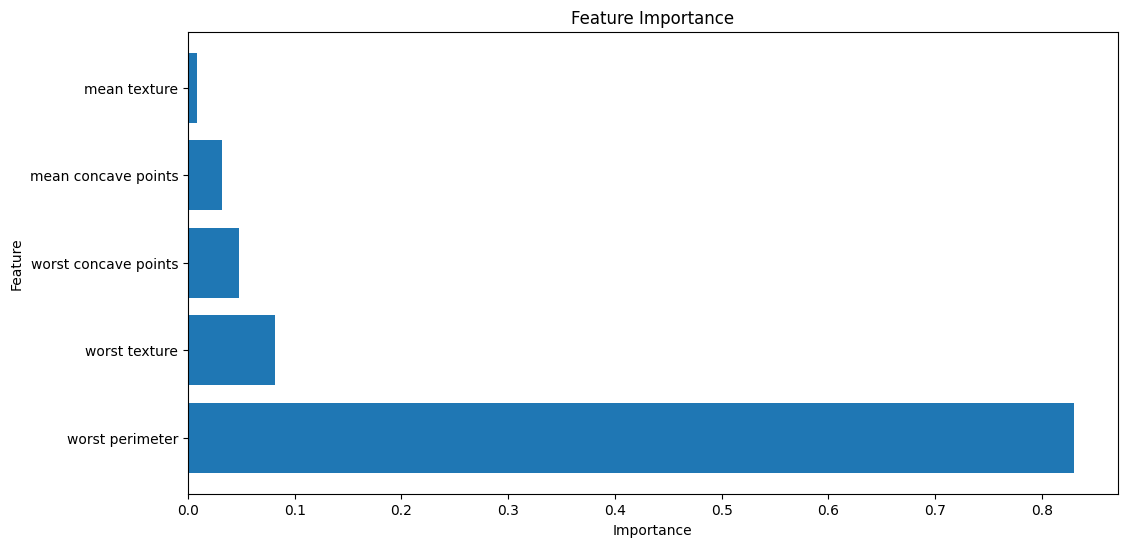

In [27]:
# Filtrar las características con una importancia mayor que 0.1
df_filtered = df_importance[df_importance['Importance']>0 ]

# Graficar la importancia de las características filtradas
plt.figure(figsize=(12, 6))
plt.barh(df_filtered['Feature'], df_filtered['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')
plt.show()

# Definir los mejores parametros

In [29]:
# Definir los hiperparámetros y sus posibles valores
param_grid = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Crear el objeto GridSearchCV
grid_search = GridSearchCV(estimator=clf, param_grid=param_grid, cv=5)

# Ajustar el modelo
grid_search.fit(X_train, y_train)

# Obtener los mejores hiperparámetros
best_params = grid_search.best_params_
print(f"Mejores hiperparámetros: {best_params}")

# Utilizar el mejor modelo para hacer predicciones
best_clf = grid_search.best_estimator_
y_pred = best_clf.predict(X_test)

# Calcular la precisión
accuracy = metrics.accuracy_score(y_test, y_pred)
print(f"Precisión del modelo con los mejores hiperparámetros: {accuracy * 100:.2f}%")

Mejores hiperparámetros: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'splitter': 'best'}
Precisión del modelo con los mejores hiperparámetros: 94.74%


In [30]:
clf = DecisionTreeClassifier(
    criterion='gini',
    max_depth=None,
    min_samples_leaf=1,
    min_samples_split=2,
    splitter='best',
    random_state=0
)
clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=0)

In [31]:
y_pred = clf.predict(X_test)

In [33]:
accuracy = metrics.accuracy_score(y_test, y_pred)
precision = metrics.precision_score(y_test, y_pred, average='weighted')

print(f'Exactitud del modelo: {accuracy * 100:.2f}%')
print(f'Precisión del modelo: {precision * 100:.2f}%')

Exactitud del modelo: 93.86%
Precisión del modelo: 93.90%


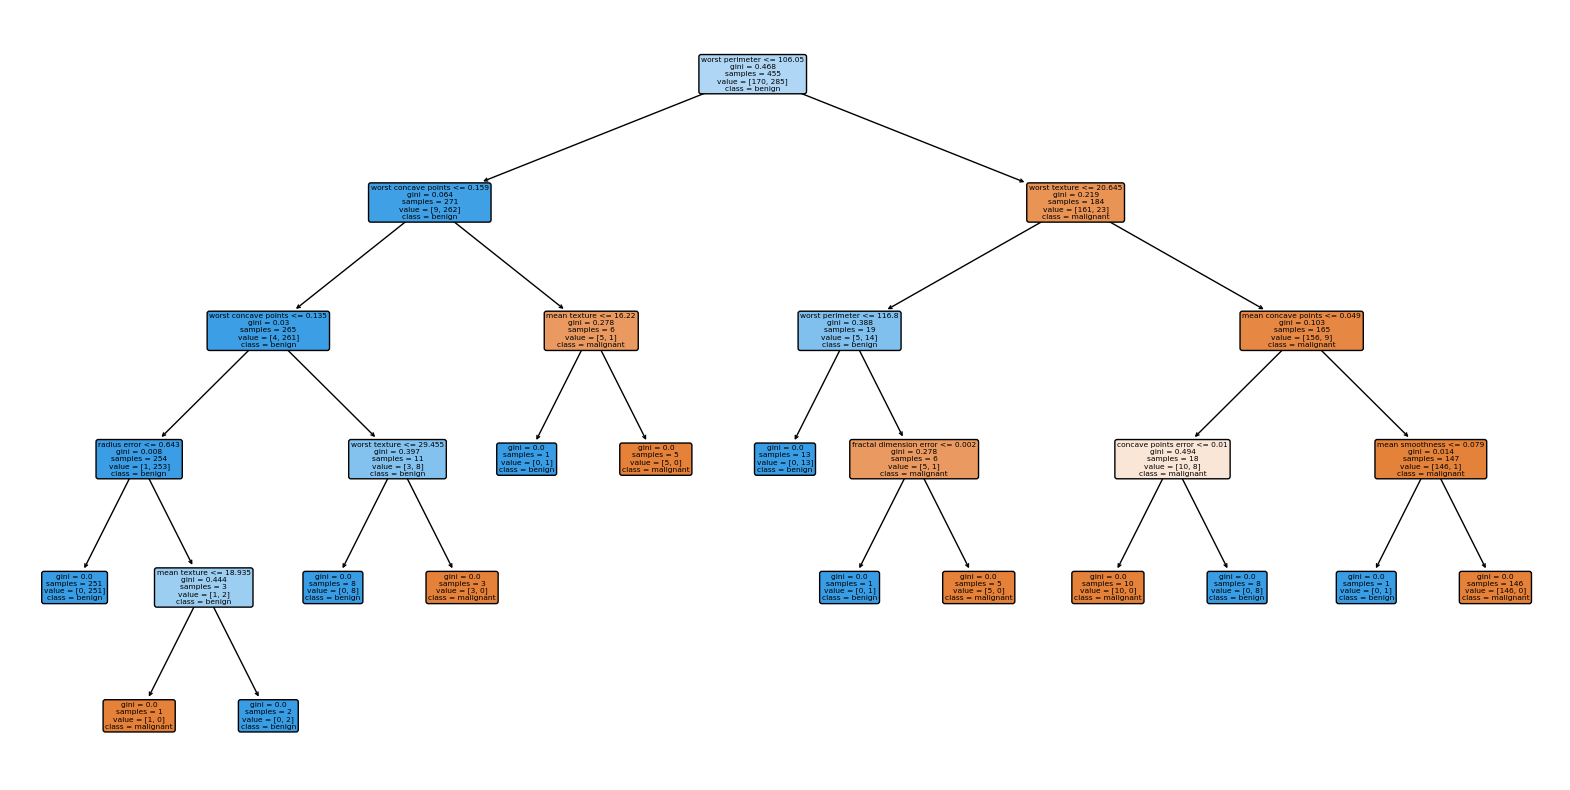

In [35]:
plt.figure(figsize=(20, 10))
tree.plot_tree(clf, filled=True, feature_names=feature_names, class_names=target_names, rounded=True)
plt.show()

In [36]:
feature_importances = clf.feature_importances_

df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Ordenar el DataFrame por importancia
df_importance = df_importance.sort_values('Importance', ascending=False)

# Mostrar la importancia de las características
df_importance

,Feature,Importance
22,worst perimeter,0.756063
21,worst texture,0.094977
27,worst concave points,0.044043
17,concave points error,0.041738
7,mean concave points,0.028844
1,mean texture,0.014087
4,mean smoothness,0.009327
19,fractal dimension error,0.007826
10,radius error,0.003093
0,mean radius,0.000000


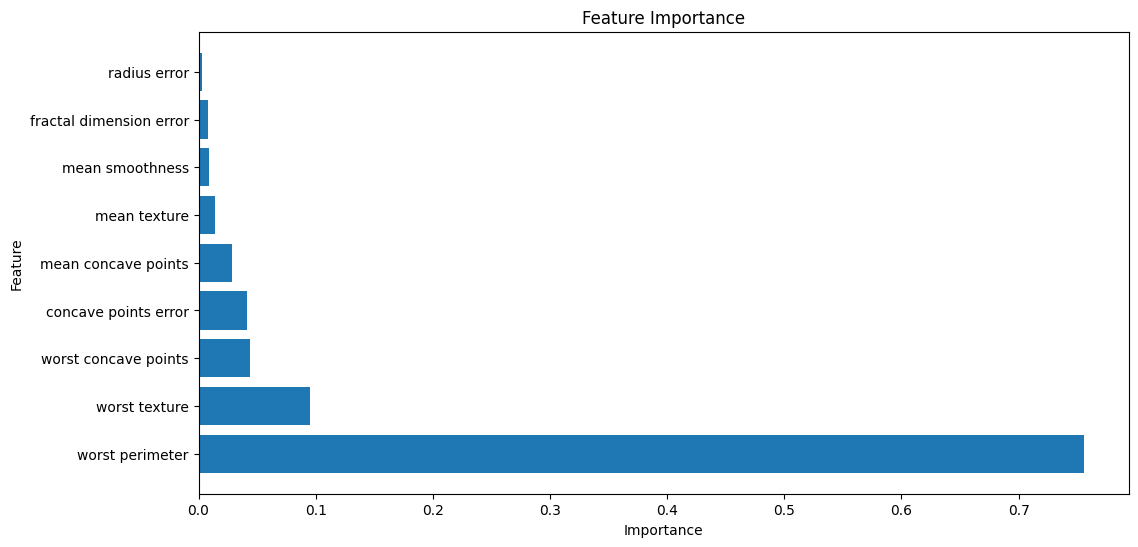

In [37]:
# Filtrar las características con una importancia mayor que 0.1
df_filtered = df_importance[df_importance['Importance']>0 ]

# Graficar la importancia de las características filtradas
plt.figure(figsize=(12, 6))
plt.barh(df_filtered['Feature'], df_filtered['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')
plt.show()

# Tecnicas de balanceo (Oversamplig)

In [40]:
# Aplicar SMOTE
smo = SMOTE(random_state=1)
X_res, y_res = smo.fit_resample(X_train, y_train)

In [41]:
import pandas as pd

# Convertir la variable objetivo a un DataFrame de Pandas
y_df = pd.DataFrame(y_res, columns=['Target'])

# Crear una tabla de frecuencia
freq_table = y_df['Target'].value_counts().reset_index()
freq_table.columns = ['Clase', 'Frecuencia']

# Si tienes los nombres de las clases, puedes reemplazar los números por los nombres
# Por ejemplo, en el conjunto de datos de cáncer de mama de sklearn, 0 representa 'maligno' y 1 representa 'benigno'
freq_table['Clase'].replace({0: 'Maligno', 1: 'Benigno'}, inplace=True)

# Mostrar la tabla de frecuencia
print(freq_table)

     Clase  Frecuencia
0  Maligno         285
1  Benigno         285


In [42]:
clf = DecisionTreeClassifier(
    criterion='gini',
    max_depth=None,
    min_samples_leaf=1,
    min_samples_split=2,
    splitter='best',
    random_state=0
)
clf.fit(X_res, y_res)

DecisionTreeClassifier(random_state=0)

In [43]:
y_pred = clf.predict(X_test)

In [45]:
accuracy = metrics.accuracy_score(y_test, y_pred)
precision = metrics.precision_score(y_test, y_pred, average='weighted')

print(f'Exactitud del modelo: {accuracy * 100:.2f}%')
print(f'Precisión del modelo: {precision * 100:.2f}%')

Exactitud del modelo: 95.61%
Precisión del modelo: 95.69%
